In [41]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [42]:
# Load the dataset
df = pd.read_csv("weight-height.csv")
print(df.head())

  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801


In [43]:
# Encode the categorical column (Gender)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0 (automatically)

In [44]:
# Extract the features and target
X = df[['Height','Gender']].values
y = df['Weight'].values

In [45]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
# Create polynomial features
poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [47]:
# Scale features (recommended for polynomial regression)
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [48]:
# Train the model
model = LinearRegression()
model.fit(X_train_poly_scaled, y_train)


LinearRegression()

In [49]:
# Make predictions
y_pred = model.predict(X_test_poly_scaled)

In [50]:

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Polynomial Regression with Gender Evaluation")
print("---------------------------------------------")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}")
print(f"R² Score: {r2:.3f}")

📊 Polynomial Regression with Gender Evaluation
---------------------------------------------
Mean Squared Error (MSE): 101.39
Root Mean Squared Error (RMSE): 10.07
R² Score: 0.903


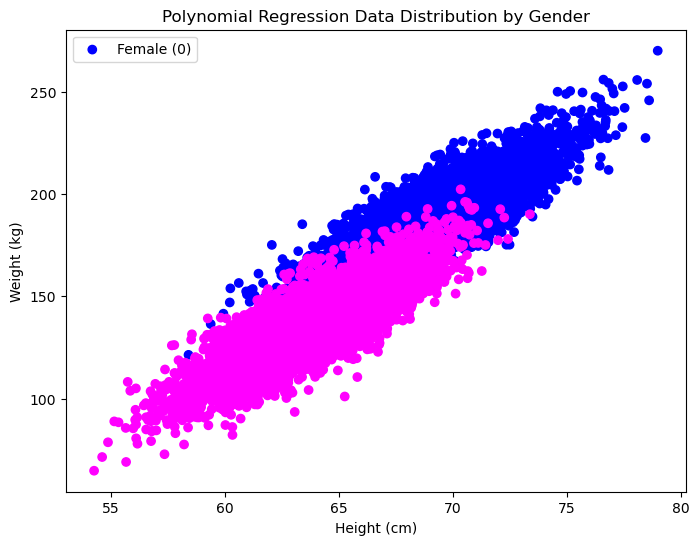

In [51]:
# Visualization (Height vs Weight with color by Gender)
plt.figure(figsize=(8,6))
colors = ['magenta' if g==0 else 'blue' for g in df['Gender']]
plt.scatter(df['Height'], df['Weight'], c=colors, label='Data points')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Polynomial Regression Data Distribution by Gender')
plt.legend(['Female (0)', 'Male (1)'])
plt.show()